In [1]:
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

## With Usual Hamiltonian

In [2]:
# Load data
        
#timeslices = [2, 4, 8, 10]
degree = [2,3,4,5]
timeslices2 = [2,4,6,8]

grape_inf = []
pulseoptim_inf = []
pop_inf = []

for n_ts in degree:
    with h5py.File(f"RND_qutip_opt_results_qubits_{n_ts}_100.hdf5", 'r') as f:
        pulseoptim_inf.append(
            f["pulseoptim_inf"][...]
        )
        grape_inf.append(
            f["grape_inf"][...]
        )

    with h5py.File(f"results_{n_ts}_100.hdf5", 'r') as f:
        pop_inf.append(1 - f['Infidelity'][...]
                            )

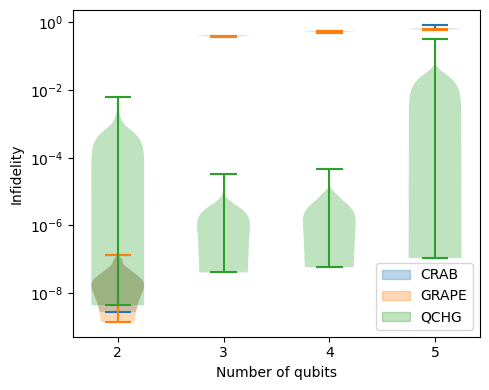

In [3]:
import matplotlib.patches as mpatches

plt.figure(figsize=(5, 4))

labels = []
def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))

# GRAPE

add_label(plt.violinplot([np.abs(_)  for _ in pulseoptim_inf]), "CRAB")
add_label(plt.violinplot([np.abs(_)  for _ in grape_inf]), "GRAPE")    


add_label(plt.violinplot([np.abs(_) for _ in pop_inf]), "QCHG")

plt.yscale('log')

plt.xticks(range(1, len(degree) + 1), degree )
plt.xlabel("Number of qubits")

plt.ylabel("Infidelity")

plt.legend(*zip(*labels), loc=4)

plt.tight_layout()

plt.savefig("Fig_grape_crab_vs_pop_magnus_random_extra5_HG_2.pdf")

plt.show()

In [4]:
grape_inf

[array([4.58793725e-09, 1.42844980e-08, 2.17741551e-08, 7.64243648e-08,
        2.63192612e-08, 4.96663735e-08, 8.31195313e-09, 4.21210157e-08,
        2.00109656e-08, 1.55835270e-08, 1.34640712e-08, 8.55787341e-09,
        4.37998608e-08, 5.81412716e-08, 3.07953599e-08, 4.56263443e-08,
        7.83657583e-09, 1.63806730e-08, 7.11980652e-09, 1.41666272e-08,
        1.84104864e-08, 2.58424160e-09, 2.63684672e-08, 6.43663722e-09,
        1.10128085e-07, 8.16396980e-08, 5.66693098e-08, 9.66304037e-09,
        1.07909675e-08, 8.39011316e-09, 3.96441797e-08, 5.63222192e-08,
        1.61555129e-08, 5.12341091e-08, 1.68220371e-09, 1.21343700e-08,
        5.27225115e-08, 2.31288604e-08, 3.68495361e-08, 1.07507354e-08,
        9.63005236e-08, 1.36573416e-07, 5.04765296e-09, 1.17781979e-08,
        2.12109196e-08, 3.00986140e-08, 9.10801101e-09, 5.06786535e-08,
        1.41083689e-09, 5.39763656e-09, 3.59483000e-08, 7.04140312e-08,
        1.54519930e-08, 1.87271434e-08, 5.34221832e-08, 9.825062

In [5]:
pu

NameError: name 'pu' is not defined